# Default versus globally fitted BinnedSED shapes with Poisson fluctuations

This tutorial compares two simultaneous true-energy SED fits:

1. `BinnedSED.from_response(response)`, whose default within-bin shape is a power law with index $-2$;
2. a global forward-folded spectral fit followed by `BinnedSED.from_response(response, spectral_shape=global_shape)`.

Both SED fits leave every bin normalization free and fit the same independent background scale. The second method freezes a copy of the globally fitted spectral shape inside the SED bins; it does **not** freeze the SED-bin normalizations.

Each injected case uses one reproducible Poisson realization of the total source-plus-background expectation. The global fit and both SED methods use exactly the same counts for that case.

The controlled cases are power laws with indices $-1$, $-2$, and $-3$, and cutoff power laws with index $-2$ and cutoff energies 200, 1000, and 5000 keV. Source expectations are generated in memory with `SourceInjector`. No injected histograms, tables, or figures are written to disk. The figures are displayed only as notebook outputs.

## 1. Imports and configuration

The DC4 background was produced with a 60-degree field-of-view selection around the source, so the same cut is applied to the orientation in memory.

In [1]:
from copy import deepcopy
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astromodels import Cutoff_powerlaw, Model, Parameter, PointSource, Powerlaw
from threeML import DataList, JointLikelihood, PluginPrototype, update_logging_level

from cosipy import BinnedData
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.response import BinnedInstrumentResponse, PointSourceResponse
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.integrals import get_integral_values
from cosipy.source_injector import SourceInjector
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml import BinnedSED, profile_likelihood_upper_limit

update_logging_level("ERROR")
%matplotlib inline

DC4_DATA_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)
ORIENTATION_PATH = DC4_DATA_DIR / (
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
)
RESPONSE_PATH = DC4_DATA_DIR / (
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284."
    "filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
BACKGROUND_PATH = DC4_DATA_DIR / (
    "Background/Total_DC4_BG_3months_binned_data_filtered_"
    "with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5"
)
CONFIG_PATH = Path("background.yaml")

SOURCE_COORD = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")
FOV_CUT = 60 * u.deg
POWERLAW_INDICES = (-1.0, -2.0, -3.0)
CUTOFF_ENERGIES_KEV = (200.0, 1000.0, 5000.0)
CUTOFF_INDEX = -2.0
PIVOT_KEV = 1000.0
INTEGRATED_PHOTON_FLUX = 5.0e-3
GLOBAL_START_K = 1.0e-7
SED_START_FLUXES = (1.0e-9, 1.0e-7, 1.0e-5)
TS_THRESHOLD = 4.0
RANDOM_SEED = 20260909
TINY = np.finfo(float).tiny
FLUX_UNIT = 1.0 / (u.keV * u.cm**2 * u.s)

00:28:24 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=951386;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=204979;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=461513;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=824574;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=408120;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=33534;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

00:28:25 INFO      Starting 3ML!                                                                     ]8;id=404964;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=648986;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=173529;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=964598;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   ROOT minimizer not available                                                ]8;id=315789;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=742045;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1208\1208]8;;\

WARNING   Multinest minimizer not available                                           ]8;id=870181;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=832678;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

WARNING   PyGMO is not available                                                      ]8;id=920614;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=854092;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=735033;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=656416;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

WARNING   No fermitools installed                                              ]8;id=467752;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=731435;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

## 2. Load the response and background

Only the existing orientation, response, and background products are read. The injected source and combined data remain Python objects in memory.

In [2]:
def dense_values(histogram):
    values = histogram.contents
    if hasattr(values, "todense"):
        values = values.todense()
    if isinstance(values, u.Quantity):
        values = values.value
    return np.asarray(values, dtype=float)


for required_path in (ORIENTATION_PATH, RESPONSE_PATH, BACKGROUND_PATH, CONFIG_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

background_data = BinnedData(CONFIG_PATH)
background_data.load_binned_data_from_hdf5(BACKGROUND_PATH)
background_hist = background_data.binned_data.project("Em", "Phi", "PsiChi")
background_counts = dense_values(background_hist)
data_definition = EmCDSBinnedData(background_hist)

orientation = SpacecraftHistory.open(ORIENTATION_PATH)
pointing_gti = GoodTimeInterval.from_pointing_cut(
    SOURCE_COORD, orientation, FOV_CUT, earth_occ=False
)
orientation = orientation.apply_gti(pointing_gti)

detector_response = FullDetectorResponse.open(RESPONSE_PATH)
instrument_response = BinnedInstrumentResponse(detector_response, data_definition)
scatt_map = orientation.get_scatt_map(
    nside=2 * data_definition.axes["PsiChi"].nside,
    target_coord=SOURCE_COORD,
    earth_occ=True,
)
point_response = PointSourceResponse.from_scatt_map(
    SOURCE_COORD,
    data_definition,
    instrument_response,
    scatt_map,
    detector_response.axes["Ei"],
    detector_response.axes["Pol"]
    if "Pol" in detector_response.axes.labels
    else None,
)
injector = SourceInjector(response_path=RESPONSE_PATH)

ei_edges = detector_response.axes["Ei"].edges
if isinstance(ei_edges, u.Quantity):
    ei_edges = ei_edges.to_value(u.keV)
ei_edges = np.asarray(ei_edges, dtype=float)
energy = np.sqrt(ei_edges[:-1] * ei_edges[1:])

print(f"Configuration: {CONFIG_PATH}")
print(f"Selected livetime: {orientation.cumulative_livetime().to_value(u.s):,.0f} s")
print(f"SED bins: {len(energy)} from {ei_edges[0]:g} to {ei_edges[-1]:g} keV")

Configuration: background.yaml
Selected livetime: 980,415 s
SED bins: 10 from 100 to 10000 keV


## 3. Spectrum and likelihood helpers

Every injected spectrum has the same photon flux integrated over the response energy range. The likelihood is Poisson and forward folds the global model through the full point-source response on every Minuit evaluation.

In [3]:
def poisson_nll(data, model):
    data = np.asarray(data, dtype=float)
    model = np.clip(np.asarray(model, dtype=float), TINY, None)
    positive = data > 0.0
    value = np.sum(model[~positive])
    value += np.sum(
        model[positive]
        - data[positive]
        + data[positive] * np.log(data[positive] / model[positive])
    )
    return float(value)


def normalize_spectrum(shape, integrated_flux=INTEGRATED_PHOTON_FLUX):
    shape.set_units(u.keV, FLUX_UNIT)
    shape.K.value = 1.0
    coefficient = get_integral_values(
        shape, np.asarray([ei_edges[0], ei_edges[-1]], dtype=float)
    )[0]
    shape.K.value = float(integrated_flux / coefficient)
    return shape


def make_injected_spectrum(family, case_value):
    if family == "powerlaw":
        shape = Powerlaw()
        shape.piv.value = PIVOT_KEV
        shape.index.value = float(case_value)
    elif family == "cutoff_powerlaw":
        shape = Cutoff_powerlaw()
        shape.piv.value = PIVOT_KEV
        shape.index.value = CUTOFF_INDEX
        shape.xc.value = float(case_value)
    else:
        raise ValueError(f"Unknown family: {family}")
    return normalize_spectrum(shape)


def minuit_status(like):
    fmin = like.minimizer.minuit.fmin
    return {
        "valid": bool(getattr(fmin, "is_valid", False)),
        "edm": float(getattr(fmin, "edm", np.nan)),
        "call_limit": bool(getattr(fmin, "has_reached_call_limit", False)),
    }

In [4]:
class ForwardFoldedSpectrumPlugin(PluginPrototype):
    """Poisson plugin for a global spectrum plus one background scale."""

    def __init__(self, name, data, background, response, spectrum):
        self._data = np.asarray(data, dtype=float)
        self._background = np.asarray(background, dtype=float)
        self._response = response
        self._spectrum = spectrum
        parameter_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            parameter_name, 1.0, min_value=0.0, max_value=10.0, delta=0.05
        )
        super().__init__(name, {parameter_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        source = dense_values(self._response.get_expectation(self._spectrum))
        model = source + float(self.background_scale.value) * self._background
        return -poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def configured_global_shape(family, start_value):
    if family == "powerlaw":
        shape = Powerlaw()
        shape.index.value = float(start_value)
        shape.index.min_value = -4.5
        shape.index.max_value = -0.5
        shape.index.delta = 0.1
        shape.index.free = True
    elif family == "cutoff_powerlaw":
        shape = Cutoff_powerlaw()
        shape.index.value = CUTOFF_INDEX
        shape.index.free = False
        shape.xc.value = float(start_value)
        shape.xc.min_value = 100.0
        shape.xc.max_value = 20000.0
        shape.xc.delta = 0.1 * float(start_value)
        shape.xc.free = True
    else:
        raise ValueError(f"Unknown family: {family}")

    shape.piv.value = PIVOT_KEV
    shape.piv.free = False
    shape.K.value = GLOBAL_START_K
    shape.K.min_value = 1.0e-12
    shape.K.max_value = 1.0e-2
    shape.K.delta = 0.2 * GLOBAL_START_K
    shape.K.free = True
    shape.set_units(u.keV, FLUX_UNIT)
    return shape


def fit_global_spectrum(data, family, tag, *, response=None, background=None):
    response = point_response if response is None else response
    background = background_counts if background is None else background
    starts = POWERLAW_INDICES if family == "powerlaw" else CUTOFF_ENERGIES_KEV
    candidates = []
    diagnostics = []

    for trial, start_value in enumerate(starts):
        shape = configured_global_shape(family, start_value)
        source = PointSource(
            f"global_source_{tag}_{trial}",
            l=SOURCE_COORD.galactic.l.deg,
            b=SOURCE_COORD.galactic.b.deg,
            spectral_shape=shape,
        )
        plugin = ForwardFoldedSpectrumPlugin(
            f"global_plugin_{tag}_{trial}",
            data, background, response, shape,
        )
        like = JointLikelihood(
            Model(source), DataList(plugin), verbose=False, record=False
        )
        like.set_minimizer("minuit")

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = minuit_status(like)
            nll = float(like.current_minimum)
            error = ""
        except Exception as exc:
            status = {"valid": False, "edm": np.nan, "call_limit": False}
            nll = np.inf
            error = f"{type(exc).__name__}: {exc}"

        diagnostics.append(
            {
                "family": family, "tag": tag, "start": start_value,
                "nll": nll, "error": error, **status,
            }
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append(
                {
                    "nll": nll,
                    "shape": deepcopy(shape),
                    "background_scale": float(plugin.background_scale.value),
                }
            )

    if not candidates:
        table = pd.DataFrame(diagnostics)
        raise RuntimeError(f"No valid global fit for {tag}:\n{table}")

    best = min(candidates, key=lambda row: row["nll"])
    best["diagnostics"] = pd.DataFrame(diagnostics)
    return best

## 4. Simultaneous BinnedSED fitting

The plugin below uses one response-folded template per true-energy bin. The amplitudes are the actual `BinnedSED` $K_i$ parameters and are fitted simultaneously with the background scale using 3ML/Minuit. Both shape choices use identical, data-independent normalization starts. For each bin, the manual profile-likelihood calculation compares the stable fit with a null fit in which only that bin is fixed to zero; all other bin amplitudes and the background scale are re-fitted. Bins with $TS < 4$ are displayed as one-sided 95% upper limits.

In [5]:
class BinnedSEDTemplatePlugin(PluginPrototype):
    """Poisson plugin driven by BinnedSED normalization parameters."""

    def __init__(self, name, data, background, templates, source_name, reference_flux):
        self._data = np.asarray(data, dtype=float).ravel()
        self._background = np.asarray(background, dtype=float).ravel()
        self._source_name = source_name
        self._templates = np.asarray(templates, dtype=float).reshape(len(energy), -1)
        self._reference_flux = float(reference_flux)
        parameter_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            parameter_name, 1.0, min_value=0.0, max_value=10.0, delta=0.05
        )
        super().__init__(name, {parameter_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        spectrum = self._model[self._source_name].spectrum.main.shape
        fluxes = np.asarray(
            [parameter.value for parameter in spectrum.normalizations], dtype=float
        )
        model = (
            float(self.background_scale.value) * self._background
            + np.sum(
                fluxes[:, None] / self._reference_flux * self._templates, axis=0
            )
        )
        return -poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def folded_sed_templates(spectrum, reference_flux, response=None):
    response = point_response if response is None else response
    templates = []
    saved = np.asarray([p.value for p in spectrum.normalizations], dtype=float)
    try:
        for parameter in spectrum.normalizations:
            parameter.value = 0.0
        for parameter in spectrum.normalizations:
            parameter.value = reference_flux
            templates.append(dense_values(response.get_expectation(spectrum)))
            parameter.value = 0.0
    finally:
        for parameter, value in zip(spectrum.normalizations, saved):
            parameter.value = float(value)
    return np.asarray(templates)


def fit_binned_sed(data, tag, spectral_shape=None, *, response=None, background=None):
    response = point_response if response is None else response
    background = background_counts if background is None else background
    reference_flux = SED_START_FLUXES[1]
    spectrum = BinnedSED.from_response(
        detector_response,
        spectral_shape=spectral_shape,
        initial_fluxes=np.full(len(energy), reference_flux),
    )
    source_name = f"sed_source_{tag}"
    source = PointSource(
        source_name,
        l=SOURCE_COORD.galactic.l.deg,
        b=SOURCE_COORD.galactic.b.deg,
        spectral_shape=spectrum,
    )
    parameters = tuple(spectrum.normalizations)
    templates = folded_sed_templates(spectrum, reference_flux, response)
    plugin = BinnedSEDTemplatePlugin(
        f"sed_plugin_{tag}",
        data, background, templates, source_name, reference_flux,
    )
    like = JointLikelihood(
        Model(source), DataList(plugin), verbose=False, record=False
    )
    like.set_minimizer("minuit")

    candidates = []
    diagnostics = []
    first_exception = None
    for start_flux in SED_START_FLUXES:
        for parameter in parameters:
            parameter.value = start_flux
            parameter.delta = 0.2 * start_flux
            parameter.free = True
        plugin.background_scale.value = 1.0
        plugin.background_scale.free = True

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = minuit_status(like)
            nll = float(like.current_minimum)
            error = ""
        except Exception as exc:
            if first_exception is None:
                first_exception = exc
            status = {"valid": False, "edm": np.nan, "call_limit": False}
            nll = np.inf
            error = f"{type(exc).__name__}: {exc}"

        diagnostics.append(
            {"tag": tag, "start_flux": start_flux, "nll": nll,
             "error": error, **status}
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append(
                (
                    nll,
                    np.asarray([p.value for p in parameters], dtype=float),
                    float(plugin.background_scale.value),
                )
            )

    if not candidates:
        table = pd.DataFrame(diagnostics)
        raise RuntimeError(
            f"No valid BinnedSED fit for {tag}:\n{table}"
        ) from first_exception

    _, best_fluxes, best_background = min(candidates, key=lambda row: row[0])
    for parameter, value in zip(parameters, best_fluxes):
        parameter.value = float(value)
        parameter.delta = max(0.2 * float(value), 1.0e-12)
    plugin.background_scale.value = best_background
    like.fit(quiet=True, compute_covariance=True)
    baseline_fluxes = np.asarray([p.value for p in parameters], dtype=float)
    baseline_background = float(plugin.background_scale.value)
    baseline_nll = float(like.current_minimum)

    errors = []
    for parameter in parameters:
        minuit_name = parameter.path.replace(".", "_")
        try:
            errors.append(float(like.minimizer.minuit.errors[minuit_name]))
        except Exception:
            errors.append(np.nan)

    # Manual per-bin profile-likelihood TS: set K_i=0, keep it fixed,
    # and refit every other SED normalization and the background scale.
    ts_values = []
    ts_diagnostics = []
    for bin_index, parameter in enumerate(parameters):
        for other_parameter, value in zip(parameters, baseline_fluxes):
            other_parameter.value = float(value)
            other_parameter.free = True
        plugin.background_scale.value = baseline_background
        plugin.background_scale.free = True
        parameter.value = 0.0
        parameter.free = False
        like.fit(quiet=True, compute_covariance=False)
        null_nll = float(like.current_minimum)
        raw_ts = 2.0 * (null_nll - baseline_nll)
        ts_values.append(max(0.0, raw_ts))
        ts_diagnostics.append(
            {"bin": bin_index,
             "null_nll": null_nll,
             "alternative_nll": baseline_nll,
             "TS": max(0.0, raw_ts)}
        )

    # Restore the stable alternative fit after the null scans.
    for parameter, value in zip(parameters, baseline_fluxes):
        parameter.value = float(value)
        parameter.free = True
    plugin.background_scale.value = baseline_background
    plugin.background_scale.free = True

    ts_values = np.asarray(ts_values, dtype=float)
    is_ul = ts_values < TS_THRESHOLD
    ul95 = np.full(len(parameters), np.nan, dtype=float)
    for bin_index in np.flatnonzero(is_ul):
        parameter = parameters[bin_index]

        def conditional_nll(value):
            saved_value = float(parameter.value)
            parameter.value = float(value)
            try:
                return -float(plugin.get_log_like())
            finally:
                parameter.value = saved_value

        ul95[bin_index] = profile_likelihood_upper_limit(
            conditional_nll,
            nll_best=baseline_nll,
            best_value=baseline_fluxes[bin_index],
            sigma=errors[bin_index],
            max_value=parameter.max_value,
        )

    return {
        "spectrum": spectrum,
        "flux": baseline_fluxes,
        "error": np.asarray(errors, dtype=float),
        "TS": ts_values,
        "is_ul": is_ul,
        "ul95": ul95,
        "background_scale": baseline_background,
        "nll": baseline_nll,
        "diagnostics": pd.DataFrame(diagnostics),
        "ts_diagnostics": pd.DataFrame(ts_diagnostics),
    }

## 5. Generate fluctuated counts and perform the global fits

`data_save_path=None` makes `SourceInjector` return the expected source histogram without creating an HDF5 file. We draw independent Poisson counts in every measured-energy/Compton-data-space cell with mean `source_counts + background_counts`. Sampling the sum is equivalent to independently sampling and adding source and background counts.

The background template remains the expected background, not a second noisy realization; its scale is free in the global fit and both SED fits. This simulates counting noise in the observations, but not uncertainty in the background template or response.

A fixed seed and separate random streams per case make rerunning this cell reproducible. Change `RANDOM_SEED` to explore another realization. Each realization is reused for the global fit and both SED methods; there is no resampling between methods.

In [6]:
case_definitions = [
    *(
        {"family": "powerlaw", "case_value": index,
         "case_label": rf"$\alpha={index:g}$"}
        for index in POWERLAW_INDICES
    ),
    *(
        {"family": "cutoff_powerlaw", "case_value": cutoff,
         "case_label": rf"$E_c={cutoff:g}$ keV"}
        for cutoff in CUTOFF_ENERGIES_KEV
    ),
]

comparison_runs = []
global_diagnostics = []
count_rows = []
case_seeds = np.random.SeedSequence(RANDOM_SEED).spawn(len(case_definitions))

for case_number, case in enumerate(case_definitions):
    family = case["family"]
    case_value = float(case["case_value"])
    tag = f"{family}_{case_number}"
    truth_shape = make_injected_spectrum(family, case_value)

    injected_hist = injector.inject_point_source(
        spectrum=truth_shape,
        coordinate=SOURCE_COORD,
        orientation=orientation,
        source_name=tag,
        data_save_path=None,
        project_axes=["Em", "Phi", "PsiChi"],
        earth_occ=True,
    )
    source_counts = dense_values(injected_hist)
    if source_counts.shape != background_counts.shape:
        raise ValueError(
            f"Source shape {source_counts.shape} does not match "
            f"background shape {background_counts.shape}."
        )
    expected_counts = background_counts + source_counts
    if not np.all(np.isfinite(expected_counts)) or np.any(expected_counts < 0):
        raise ValueError("Poisson expectations must be finite and non-negative.")
    rng = np.random.default_rng(case_seeds[case_number])
    data = rng.poisson(expected_counts)
    count_rows.append({
        "family": family,
        "case": case["case_label"],
        "expected_source_counts": float(source_counts.sum()),
        "expected_background_counts": float(background_counts.sum()),
        "expected_total_counts": float(expected_counts.sum()),
        "observed_total_counts": int(data.sum()),
        "total_count_pull": (
            (data.sum() - expected_counts.sum()) / np.sqrt(expected_counts.sum())
        ),
    })
    global_fit = fit_global_spectrum(data, family, tag)
    global_diagnostics.append(global_fit["diagnostics"])
    comparison_runs.append(
        {**case, "tag": tag, "truth_shape": truth_shape,
         "global_fit": global_fit, "data": data}
    )

print(f"Poisson seed: {RANDOM_SEED}; one shared realization per case")
count_summary = pd.DataFrame(count_rows)
display(count_summary)

global_rows = []
for run in comparison_runs:
    shape = run["global_fit"]["shape"]
    global_rows.append(
        {
            "family": run["family"],
            "case": run["case_label"],
            "fitted_K": float(shape.K.value),
            "fitted_index": float(shape.index.value),
            "fitted_cutoff_keV": (
                float(shape.xc.value) if hasattr(shape, "xc") else np.nan
            ),
            "background_scale": run["global_fit"]["background_scale"],
            "nll": run["global_fit"]["nll"],
        }
    )
global_fit_table = pd.DataFrame(global_rows)
display(global_fit_table)

global_start_diagnostics = pd.concat(global_diagnostics, ignore_index=True)
display(global_start_diagnostics)

Poisson seed: 20260909; one shared realization per case


,family,case,expected_source_counts,expected_background_counts,expected_total_counts,observed_total_counts,total_count_pull
0,powerlaw,$\alpha=-1$,223657.386581,25071034.0,2.529469e+07,25294046,-0.128323
1,powerlaw,$\alpha=-2$,214369.852251,25071034.0,2.528540e+07,25275252,-2.018879
2,powerlaw,$\alpha=-3$,156267.994688,25071034.0,2.522730e+07,25230489,0.634523
3,cutoff_powerlaw,$E_c=200$ keV,152491.552691,25071034.0,2.522353e+07,25225733,0.439529
4,cutoff_powerlaw,$E_c=1000$ keV,199327.598596,25071034.0,2.527036e+07,25276677,1.256305
5,cutoff_powerlaw,$E_c=5000$ keV,212373.502115,25071034.0,2.528341e+07,25268477,-2.969317


,family,case,fitted_K,fitted_index,fitted_cutoff_keV,background_scale,nll
0,powerlaw,$\alpha=-1$,1.103268e-06,-0.986731,NaN,0.999864,100102.345125
1,powerlaw,$\alpha=-2$,5.228280e-07,-1.943750,NaN,0.999807,99378.387374
2,powerlaw,$\alpha=-3$,1.007719e-07,-2.996825,NaN,1.000109,99756.990924
3,cutoff_powerlaw,$E_c=200$ keV,1.493791e-06,-2.000000,201.626692,1.000180,99395.820818
4,cutoff_powerlaw,$E_c=1000$ keV,6.921228e-07,-2.000000,1021.804612,1.000193,99321.148711
5,cutoff_powerlaw,$E_c=5000$ keV,5.440725e-07,-2.000000,4402.790542,0.999558,99416.835026


,family,tag,start,nll,error,valid,edm,call_limit
0,powerlaw,powerlaw_0,-1.0,100102.345125,,True,7.337662e-07,False
1,powerlaw,powerlaw_0,-2.0,100102.345125,,True,9.752863e-07,False
2,powerlaw,powerlaw_0,-3.0,100102.345125,,True,7.118015e-07,False
3,powerlaw,powerlaw_1,-1.0,99378.387375,,True,1.158972e-06,False
4,powerlaw,powerlaw_1,-2.0,99378.387374,,True,1.843621e-07,False
5,powerlaw,powerlaw_1,-3.0,99378.387383,,True,9.194153e-06,False
6,powerlaw,powerlaw_2,-1.0,99756.990935,,True,1.208188e-05,False
7,powerlaw,powerlaw_2,-2.0,99756.990925,,True,1.553211e-06,False
8,powerlaw,powerlaw_2,-3.0,99756.990924,,True,5.841534e-07,False
9,cutoff_powerlaw,cutoff_powerlaw_3,200.0,99395.820822,,True,3.579692e-06,False


## 6. Fit both BinnedSED methods

The default fit passes `spectral_shape=None`. The second fit passes the corresponding global best-fit power law or cutoff power law. `BinnedSED` deep-copies and freezes that shape, while all $K_i$ values remain free.

In [7]:
sed_rows = []
sed_diagnostics = []
sed_ts_diagnostics = []

for run in comparison_runs:
    fits = {
        "default E^-2": fit_binned_sed(
            run["data"], f"{run['tag']}_default", spectral_shape=None
        ),
        "global fitted shape": fit_binned_sed(
            run["data"],
            f"{run['tag']}_global_shape",
            spectral_shape=run["global_fit"]["shape"],
        ),
    }
    run["sed_fits"] = fits
    truth = np.asarray(run["truth_shape"](energy), dtype=float)

    for method, fit in fits.items():
        sed_diagnostics.append(
            fit["diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            )
        )
        sed_ts_diagnostics.append(
            fit["ts_diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            )
        )
        for bin_index, (flux, error, truth_value) in enumerate(
            zip(fit["flux"], fit["error"], truth)
        ):
            sed_rows.append(
                {
                    "family": run["family"],
                    "case": run["case_label"],
                    "case_value": run["case_value"],
                    "method": method,
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": flux,
                    "flux_error": error,
                    "TS": fit["TS"][bin_index],
                    "is_ul": bool(fit["is_ul"][bin_index]),
                    "ul95": fit["ul95"][bin_index],
                    "truth": truth_value,
                    "residual_percent": 100.0 * (flux - truth_value) / truth_value,
                    "background_scale": fit["background_scale"],
                }
            )

sed_results = pd.DataFrame(sed_rows)
sed_start_diagnostics = pd.concat(sed_diagnostics, ignore_index=True)
sed_ts_fit_diagnostics = pd.concat(sed_ts_diagnostics, ignore_index=True)
display(sed_start_diagnostics)

,tag,start_flux,nll,error,valid,edm,call_limit,family,case,method
0,powerlaw_0_default,1.000000e-09,100097.268120,,True,0.000017,False,powerlaw,$\alpha=-1$,default E^-2
1,powerlaw_0_default,1.000000e-07,100097.268110,,True,0.000024,False,powerlaw,$\alpha=-1$,default E^-2
2,powerlaw_0_default,1.000000e-05,100097.268472,,True,0.000387,False,powerlaw,$\alpha=-1$,default E^-2
3,powerlaw_0_global_shape,1.000000e-09,100097.268120,,True,0.000035,False,powerlaw,$\alpha=-1$,global fitted shape
4,powerlaw_0_global_shape,1.000000e-07,100097.268166,,True,0.000081,False,powerlaw,$\alpha=-1$,global fitted shape
5,powerlaw_0_global_shape,1.000000e-05,100097.268383,,True,0.000298,False,powerlaw,$\alpha=-1$,global fitted shape
6,powerlaw_1_default,1.000000e-09,99375.423546,,True,0.000185,False,powerlaw,$\alpha=-2$,default E^-2
7,powerlaw_1_default,1.000000e-07,99375.423398,,True,0.000029,False,powerlaw,$\alpha=-2$,default E^-2
8,powerlaw_1_default,1.000000e-05,99375.424485,,True,0.000019,False,powerlaw,$\alpha=-2$,default E^-2
9,powerlaw_1_global_shape,1.000000e-09,99375.423547,,True,0.000186,False,powerlaw,$\alpha=-2$,global fitted shape


## 7. Numerical comparison tables

The summary reports the median absolute bin-center residual from injected truth for detections only, plus the numbers of detections and upper limits. The detailed tables retain the flux, Hessian uncertainty, TS, upper-limit flag/value, residual, and jointly fitted background scale. Separate pivot tables show the TS of every bin for each method.

In [8]:
summary_rows = []
for (family, case, method), group in sed_results.groupby(
    ["family", "case", "method"]
):
    detections = group.loc[~group["is_ul"]]
    summary_rows.append(
        {"family": family, "case": case, "method": method,
         "median_absolute_residual_percent": (
             np.median(np.abs(detections["residual_percent"]))
             if len(detections) else np.nan
         ),
         "detections": len(detections),
         "upper_limits_TS_lt_4": int(group["is_ul"].sum()),
         "fitted_background_scale": group["background_scale"].iloc[0]}
    )
accuracy_summary = pd.DataFrame(summary_rows)
display(accuracy_summary)

for family in ("powerlaw", "cutoff_powerlaw"):
    print(f"Per-bin results: {family}")
    display(
        sed_results.loc[
            sed_results["family"] == family,
            ["case", "method", "bin", "energy_keV", "flux",
             "flux_error", "TS", "is_ul", "ul95", "truth",
             "residual_percent",
             "background_scale"],
        ]
    )

    for method in ("default E^-2", "global fitted shape"):
        print(f"TS table: {family} — {method}")
        ts_table = (
            sed_results.loc[
                (sed_results["family"] == family)
                & (sed_results["method"] == method),
                ["bin", "energy_keV", "case", "TS"],
            ]
            .pivot(index=["bin", "energy_keV"], columns="case", values="TS")
        )
        display(ts_table.style.format(precision=3))

,family,case,method,median_absolute_residual_percent,detections,upper_limits_TS_lt_4,fitted_background_scale
0,cutoff_powerlaw,$E_c=1000$ keV,default E^-2,6.280556,6,4,1.000342
1,cutoff_powerlaw,$E_c=1000$ keV,global fitted shape,6.152678,6,4,1.000342
2,cutoff_powerlaw,$E_c=200$ keV,default E^-2,1.331246,4,6,1.000150
3,cutoff_powerlaw,$E_c=200$ keV,global fitted shape,2.810932,4,6,1.000149
4,cutoff_powerlaw,$E_c=5000$ keV,default E^-2,6.506289,7,3,0.999561
5,cutoff_powerlaw,$E_c=5000$ keV,global fitted shape,6.390040,7,3,0.999561
6,powerlaw,$\alpha=-1$,default E^-2,4.027769,10,0,1.000069
7,powerlaw,$\alpha=-1$,global fitted shape,4.352046,10,0,1.000069
8,powerlaw,$\alpha=-2$,default E^-2,5.120292,9,1,0.999795
9,powerlaw,$\alpha=-2$,global fitted shape,5.028706,9,1,0.999795


Per-bin results: powerlaw


,case,method,bin,energy_keV,flux,flux_error,TS,is_ul,ul95,truth,residual_percent,background_scale
0,$\alpha=-1$,default E^-2,0,125.892414,8.969258e-06,2.216099e-06,21.274898,False,NaN,8.624318e-06,3.999618,1.000069
1,$\alpha=-1$,default E^-2,1,199.526172,4.301267e-06,5.277896e-07,66.687070,False,NaN,5.441573e-06,-20.955442,1.000069
2,$\alpha=-1$,default E^-2,2,316.227923,3.298214e-06,1.978305e-07,282.074646,False,NaN,3.433398e-06,-3.937302,1.000069
3,$\alpha=-1$,default E^-2,3,501.186989,2.162408e-06,9.860680e-08,492.109609,False,NaN,2.166330e-06,-0.181042,1.000069
4,$\alpha=-1$,default E^-2,4,794.328018,1.387817e-06,5.668784e-08,625.066958,False,NaN,1.366861e-06,1.533117,1.000069
5,$\alpha=-1$,default E^-2,5,1258.924144,9.307391e-07,3.790711e-08,628.825701,False,NaN,8.624318e-07,7.920314,1.000069
6,$\alpha=-1$,default E^-2,6,1995.261723,5.220867e-07,2.704188e-08,392.088674,False,NaN,5.441573e-07,-4.055919,1.000069
7,$\alpha=-1$,default E^-2,7,3162.279229,3.732843e-07,3.108956e-08,151.268396,False,NaN,3.433398e-07,8.721542,1.000069
8,$\alpha=-1$,default E^-2,8,5011.869895,1.935765e-07,3.194171e-08,35.579979,False,NaN,2.166330e-07,-10.643118,1.000069
9,$\alpha=-1$,default E^-2,9,7943.280179,1.406312e-07,1.616936e-08,67543.244954,False,NaN,1.366861e-07,2.886229,1.000069


TS table: powerlaw — default E^-2


,case,$\alpha=-1$,$\alpha=-2$,$\alpha=-3$
bin,energy_keV,,,
0,125.892414,21.275,169.134,546.567
1,199.526172,66.687,525.130,607.935
2,316.227923,282.075,640.478,286.299
3,501.186989,492.110,420.463,91.752
4,794.328018,625.067,226.120,13.379
5,1258.924144,628.826,81.035,0.146
6,1995.261723,392.089,37.530,0.000
7,3162.279229,151.268,21.852,0.000
8,5011.869895,35.580,0.000,1.399


...

,case,method,bin,energy_keV,flux,flux_error,TS,is_ul,ul95,truth,residual_percent,background_scale
60,$E_c=200$ keV,default E^-2,0,125.892414,5.063543e-05,1.113458e-06,553.325883,False,NaN,5.146648e-05,-1.614746e+00,1.000150
61,$E_c=200$ keV,default E^-2,1,199.526172,1.432705e-05,2.181694e-07,784.236634,False,NaN,1.417850e-05,1.047746e+00,1.000150
62,$E_c=200$ keV,default E^-2,2,316.227923,3.156565e-06,9.016780e-08,274.563756,False,NaN,3.149306e-06,2.304794e-01,1.000150
63,$E_c=200$ keV,default E^-2,3,501.186989,6.267826e-07,7.119125e-08,42.199314,False,NaN,4.972585e-07,2.604765e+01,1.000150
64,$E_c=200$ keV,default E^-2,4,794.328018,2.933653e-14,4.715695e-09,0.000000,True,4.866387e-08,4.571244e-08,-9.999994e+01,1.000150
65,$E_c=200$ keV,default E^-2,5,1258.924144,7.259349e-13,5.103442e-03,0.000000,True,5.908453e-08,1.783107e-09,-9.995929e+01,1.000150
66,$E_c=200$ keV,default E^-2,6,1995.261723,2.079627e-08,6.649179e-08,0.719074,True,6.127980e-08,1.787475e-11,1.162444e+05,1.000150
67,$E_c=200$ keV,default E^-2,7,3162.279229,5.892509e-15,9.538479e-10,0.000000,True,1.257846e-08,2.080142e-14,-7.167256e+01,1.000150
68,$E_c=200$ keV,default E^-2,8,5011.869895,4.374279e-16,3.471861e-10,0.000000,True,4.999239e-09,7.975515e-19,5.474635e+04,1.000150
69,$E_c=200$ keV,default E^-2,9,7943.280179,6.566969e-16,1.184994e-10,0.000000,True,1.731806e-09,1.368617e-25,4.798251e+11,1.000150


TS table: cutoff_powerlaw — default E^-2


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,265.593,553.326,184.883
1,199.526172,2111.333,784.237,636.571
2,316.227923,778.482,274.564,635.802
3,501.186989,313.168,42.199,476.140
4,794.328018,68.910,0.000,146.989
5,1258.924144,7.437,0.000,51.466
6,1995.261723,0.469,0.719,21.755
7,3162.279229,0.000,0.000,2.815
8,5011.869895,0.000,0.000,2.141


TS table: cutoff_powerlaw — global fitted shape


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,265.593,553.326,184.883
1,199.526172,2111.333,784.237,636.571
2,316.227923,778.482,274.564,635.803
3,501.186989,313.168,42.199,476.140
4,794.328018,68.910,0.000,146.989
5,1258.924144,7.436,0.000,51.466
6,1995.261723,0.469,0.720,21.755
7,3162.279229,0.000,0.000,2.815
8,5011.869895,0.000,0.000,2.141


## 8. Inline SED and residual plots

Each row is one injection. The left panel shows injected truth, the global fit, and both SED reconstructions. Ordinary circles/diamonds have $TS \geq 4$; white-filled downward triangles show the one-sided 95% upper limits for bins with $TS < 4$ in every panel. The SED panels stop at $10^{-5}$ for readability. The log-log panels on the right show the reported value divided by injected truth, with a horizontal reference at one. No `savefig` call is made.

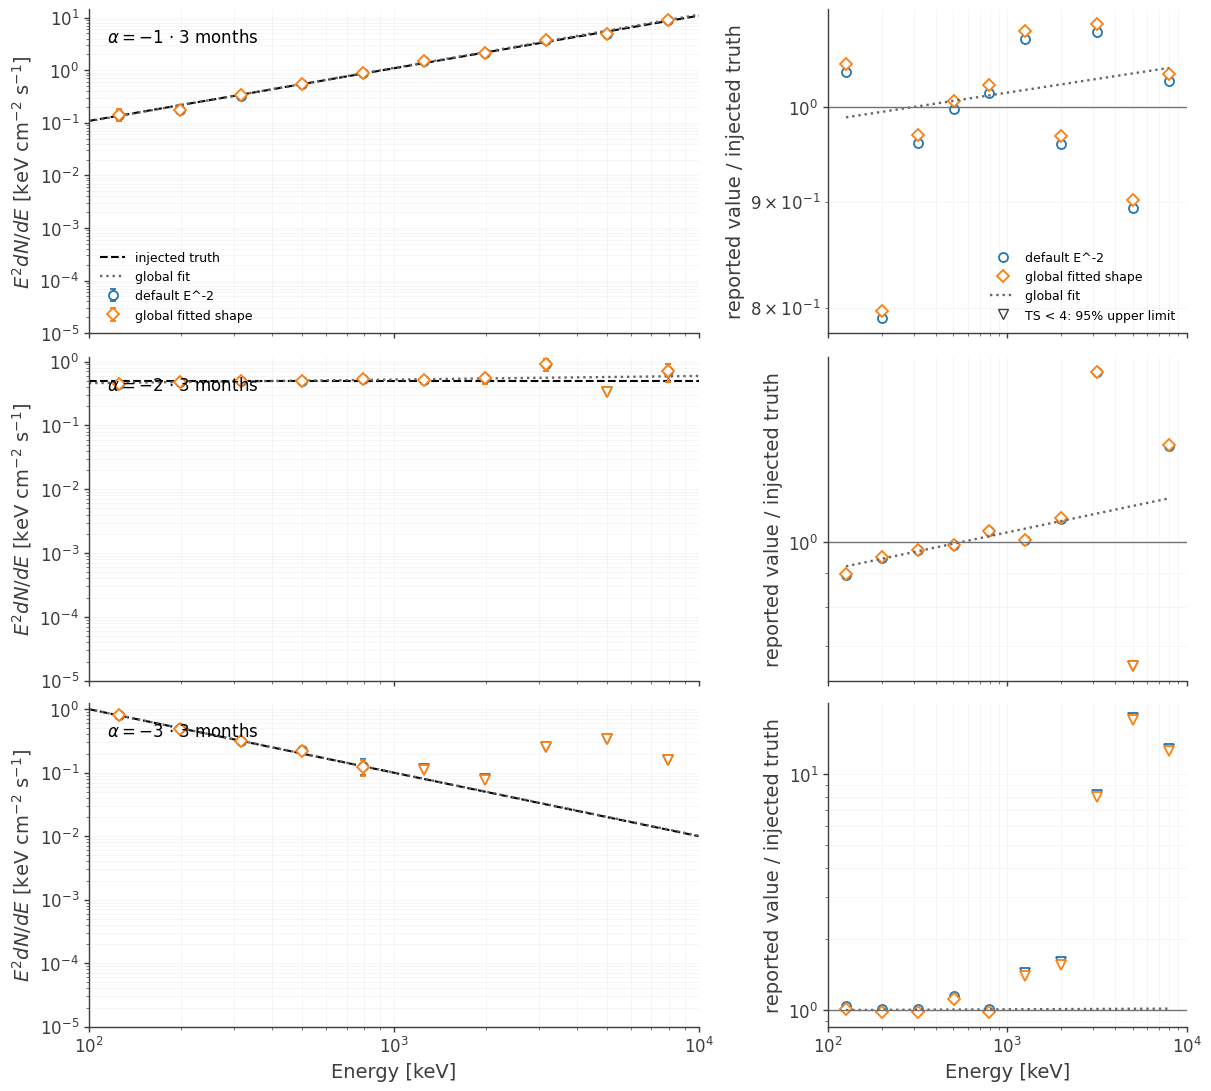

In [9]:
METHOD_STYLE = {
    "default E^-2": {"marker": "o", "color": "tab:blue"},
    "global fitted shape": {"marker": "D", "color": "tab:orange"},
}


def plot_family_comparison(family, runs=None, results=None, exposure_months=3):
    runs = comparison_runs if runs is None else runs
    results = sed_results if results is None else results
    selected_runs = [run for run in runs if run["family"] == family]
    fig, axes = plt.subplots(
        len(selected_runs), 2, figsize=(12, 3.6 * len(selected_runs)),
        sharex="col", gridspec_kw={"width_ratios": (1.7, 1.0)},
        layout="constrained",
    )
    plot_energy = np.geomspace(ei_edges[0], ei_edges[-1], 500)

    for row, run in enumerate(selected_runs):
        ax_sed, ax_residual = axes[row]
        truth_curve = np.asarray(run["truth_shape"](plot_energy), dtype=float)
        global_shape = run["global_fit"]["shape"]
        global_curve = np.asarray(global_shape(plot_energy), dtype=float)
        ax_sed.plot(
            plot_energy, plot_energy**2 * truth_curve, "k--", lw=1.5,
            label="injected truth",
        )
        ax_sed.plot(
            plot_energy, plot_energy**2 * global_curve, color="0.4",
            ls=":", lw=1.7, label="global fit",
        )

        case_results = results[
            (results["family"] == family)
            & (results["case_value"] == run["case_value"])
        ]
        for method, style in METHOD_STYLE.items():
            table = case_results[case_results["method"] == method].sort_values("bin")
            x = table["energy_keV"].to_numpy()
            detected = ~table["is_ul"].to_numpy(dtype=bool)
            upper = ~detected
            y = x**2 * table["flux"].to_numpy()
            yerr = x**2 * table["flux_error"].to_numpy()
            ax_sed.errorbar(
                x[detected], y[detected], yerr=yerr[detected],
                fmt=style["marker"], ms=6.5, capsize=2,
                color=style["color"], markerfacecolor="white",
                markeredgewidth=1.3, linestyle="none", label=method,
            )
            if np.any(upper):
                ul_y = x[upper]**2 * table.loc[upper, "ul95"].to_numpy()
                ax_sed.plot(
                    x[upper], ul_y, marker="v", ms=6.5,
                    color=style["color"], markerfacecolor="white",
                    markeredgewidth=1.3, linestyle="none",
                )
            detection_ratio = (
                table.loc[detected, "flux"].to_numpy()
                / table.loc[detected, "truth"].to_numpy()
            )
            ax_residual.plot(
                x[detected], detection_ratio,
                marker=style["marker"],
                ms=6.5, color=style["color"], markerfacecolor="white",
                markeredgewidth=1.3, linestyle="none", label=method,
            )
            if np.any(upper):
                ul_ratio = (
                    table.loc[upper, "ul95"].to_numpy()
                    / table.loc[upper, "truth"].to_numpy()
                )
                ax_residual.plot(
                    x[upper], ul_ratio, marker="v", ms=6.5,
                    color=style["color"], markerfacecolor="white",
                    markeredgewidth=1.3, linestyle="none",
                )

        global_at_bins = np.asarray(global_shape(energy), dtype=float)
        truth_at_bins = np.asarray(run["truth_shape"](energy), dtype=float)
        global_ratio = global_at_bins / truth_at_bins
        ax_residual.plot(
            energy, global_ratio, color="0.4", ls=":", lw=1.7,
            label="global fit",
        )

        ax_sed.text(0.03, 0.94, f"{run['case_label']} · {exposure_months:g} months", transform=ax_sed.transAxes, va="top")
        ax_sed.set_xscale("log")
        ax_sed.set_yscale("log")
        ax_sed.set_xlim(ei_edges[0], ei_edges[-1])
        ax_sed.set_ylim(bottom=1.0e-5)
        ax_sed.set_ylabel(r"$E^2 dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
        ax_sed.grid(alpha=0.2, which="both")
        ax_residual.axhline(1.0, color="0.45", lw=1.0)
        ax_residual.set_xscale("log")
        ax_residual.set_yscale("log")
        ax_residual.set_xlim(ei_edges[0], ei_edges[-1])
        ax_residual.set_ylabel("reported value / injected truth")
        ax_residual.grid(alpha=0.2, which="both")

        if row == 0:
            ax_residual.plot(
                [], [], marker="v", ms=6.5, color="0.25",
                markerfacecolor="white", linestyle="none",
                label="TS < 4: 95% upper limit",
            )
            ax_sed.legend(frameon=False, fontsize=9)
            ax_residual.legend(frameon=False, fontsize=9)

    axes[-1, 0].set_xlabel("Energy [keV]")
    axes[-1, 1].set_xlabel("Energy [keV]")
    plt.show()


plot_family_comparison("powerlaw")

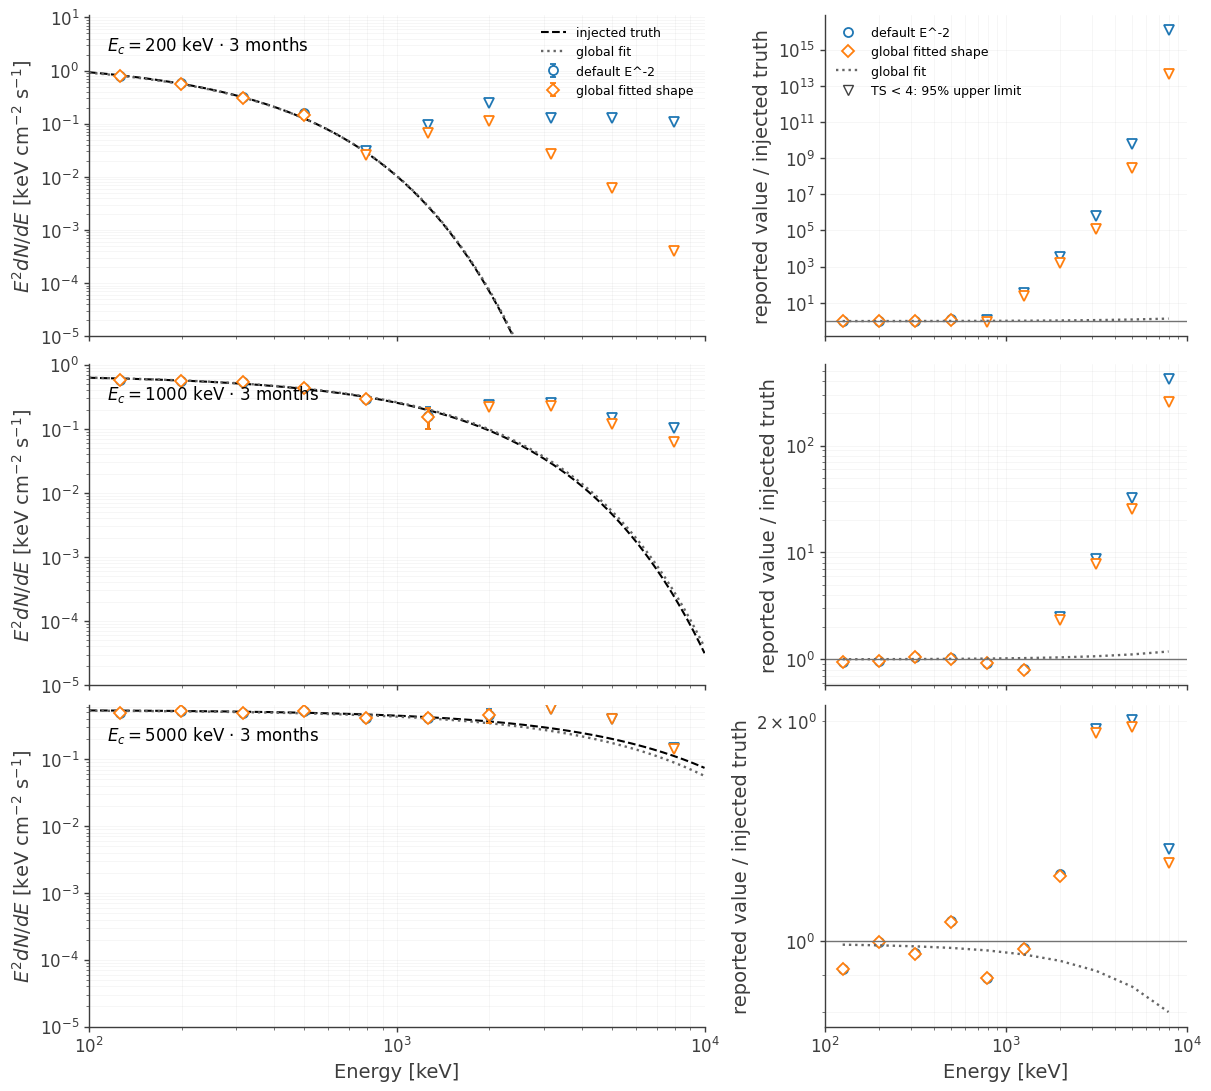

In [10]:
plot_family_comparison("cutoff_powerlaw")

## Interpretation

Unlike the Asimov companion notebook, the fitted points now fluctuate around the injected truth. Even for the injected $\alpha=-2$ control, the globally fitted index can differ from $-2$, so the two SED shapes need not be identical. A correct global model family can reduce within-bin shape mismatch, but it does not guarantee that every fitted point is closer to truth in one realization. Every SED-bin normalization remains free.

The global shape is estimated from the same counts and then frozen. Its uncertainty is not propagated into the SED errors. The displayed Hessian bars include the fitted background nuisance parameter for both methods, but do not encode cross-method covariance; both reconstructions use the same noisy data.

As in the companion notebook, TS uses refits with the tested bin set to zero and the remaining normalizations and background free. Bins with TS < 4 are shown as upper limits. The 95% upper-limit calculation holds the other parameters at their best-fit values (a conditional likelihood scan), rather than profiling them at every trial flux.

The residual summaries describe this single realization, not ensemble bias. Comparing bias, variance, or interval coverage requires many independent realizations, including a consistent treatment of nondetections.

## 9. Repeat the comparison at 24 months

The `AGN_Paper_Plots` branch's `AGN_Corona_Paper_Plots_TH_NTH_Comp.ipynb` uses `multiplier_4151 = 8` and `exposure_4151 = multiplier_4151 * 3`, scaling the source and background counts. Here we retain the current DC4 files and keep the **physical injected spectrum unchanged**. The orientation's livetime weights and the exposure-integrated point-source response are also multiplied by eight, so fitting does not interpret the extra counts as a brighter source.

This is an effective-exposure projection: eight repeats of the same already FOV-cut attitude/occultation distribution. We retain the original timestamps and spacecraft geometry, and multiply their statistical exposure weights; this weighted orientation is not a chronological 24-month spacecraft history and should not be used for time-domain analyses.

For each case we draw fresh counts from $\mathrm{Poisson}[8(S+B)]$, **not** $8\,\mathrm{Poisson}(S+B)$. Expected counts increase by eight, the Poisson standard deviation by $\sqrt{8}$, and its ratio to the expected source signal decreases by $1/\sqrt{8}\simeq0.354$. This does not guarantee that every fitted point in one realization improves. Both methods share the same new counts, use the same data-independent flux starts as before, and leave the background scale free. Global shapes are fitted anew to the 24-month data. The TS threshold and conditional upper-limit convention remain unchanged.

In [11]:
BASE_EXPOSURE_MONTHS = 3.0
LONG_EXPOSURE_MONTHS = 24.0
EXPOSURE_FACTOR = LONG_EXPOSURE_MONTHS / BASE_EXPOSURE_MONTHS

# Exposure-weighted reuse of the already FOV-selected geometry.
# No extra factor is applied to truth_shape.K: source counts scale through
# the orientation, while the fit uses the correspondingly scaled response.
orientation_24m = SpacecraftHistory(
    obstime=orientation.obstime,
    attitude=orientation.attitude,
    location=orientation.location,
    livetime=orientation.livetime * EXPOSURE_FACTOR,
)
background_counts_24m = background_counts * EXPOSURE_FACTOR
scatt_map_24m = orientation_24m.get_scatt_map(
    nside=2 * data_definition.axes["PsiChi"].nside,
    target_coord=SOURCE_COORD,
    earth_occ=True,
)
np.testing.assert_allclose(
    scatt_map_24m.weights, EXPOSURE_FACTOR * scatt_map.weights, rtol=1e-10
)
point_response_24m = PointSourceResponse.from_scatt_map(
    SOURCE_COORD, data_definition, instrument_response, scatt_map_24m,
    detector_response.axes["Ei"],
    detector_response.axes["Pol"]
    if "Pol" in detector_response.axes.labels else None,
)
np.testing.assert_allclose(
    orientation_24m.cumulative_livetime().to_value(u.s),
    EXPOSURE_FACTOR * orientation.cumulative_livetime().to_value(u.s),
)

display(pd.DataFrame({
    "exposure_months": [BASE_EXPOSURE_MONTHS, LONG_EXPOSURE_MONTHS],
    "selected_livetime_s": [
        orientation.cumulative_livetime().to_value(u.s),
        orientation_24m.cumulative_livetime().to_value(u.s),
    ],
    "expected_background_counts": [
        background_counts.sum(), background_counts_24m.sum(),
    ],
    "relative_Poisson_noise_vs_3m": [1.0, 1.0 / np.sqrt(EXPOSURE_FACTOR)],
}))

,exposure_months,selected_livetime_s,expected_background_counts,relative_Poisson_noise_vs_3m
0,3.0,980415.0,25071034.0,1.000000
1,24.0,7843320.0,200568272.0,0.353553


### Generate new 24-month counts and refit the global spectra

A separate deterministic seed stream leaves the original 3-month realization unchanged. The checks below verify source-injection and fitting-response scaling in every data-space bin.

In [12]:
comparison_runs_24m = []
global_diagnostics_24m = []
count_rows_24m = []
case_seeds_24m = np.random.SeedSequence([RANDOM_SEED, int(LONG_EXPOSURE_MONTHS)]).spawn(len(case_definitions))

for case_number, case in enumerate(case_definitions):
    family = case["family"]
    case_value = float(case["case_value"])
    tag = f"exposure24m_{family}_{case_number}"
    truth_shape = make_injected_spectrum(family, case_value)

    injected_hist = injector.inject_point_source(
        spectrum=truth_shape,
        coordinate=SOURCE_COORD,
        orientation=orientation_24m,
        source_name=tag,
        data_save_path=None,
        project_axes=["Em", "Phi", "PsiChi"],
        earth_occ=True,
    )
    source_counts = dense_values(injected_hist)
    base_source = dense_values(point_response.get_expectation(truth_shape))
    scaled_source = dense_values(point_response_24m.get_expectation(truth_shape))
    np.testing.assert_allclose(
        scaled_source, EXPOSURE_FACTOR * base_source, rtol=1e-9, atol=1e-9
    )
    np.testing.assert_allclose(source_counts, scaled_source, rtol=1e-9, atol=1e-9)
    if source_counts.shape != background_counts_24m.shape:
        raise ValueError(
            f"Source shape {source_counts.shape} does not match "
            f"background shape {background_counts_24m.shape}."
        )
    expected_counts = background_counts_24m + source_counts
    if not np.all(np.isfinite(expected_counts)) or np.any(expected_counts < 0):
        raise ValueError("Poisson expectations must be finite and non-negative.")
    rng = np.random.default_rng(case_seeds_24m[case_number])
    data = rng.poisson(expected_counts)
    count_rows_24m.append({
        "family": family,
        "case": case["case_label"],
        "expected_source_counts": float(source_counts.sum()),
        "expected_background_counts": float(background_counts_24m.sum()),
        "expected_total_counts": float(expected_counts.sum()),
        "observed_total_counts": int(data.sum()),
        "total_count_pull": (
            (data.sum() - expected_counts.sum()) / np.sqrt(expected_counts.sum())
        ),
    })
    global_fit = fit_global_spectrum(
        data, family, tag,
        response=point_response_24m, background=background_counts_24m,
    )
    global_diagnostics_24m.append(global_fit["diagnostics"])
    comparison_runs_24m.append(
        {**case, "tag": tag, "truth_shape": truth_shape,
         "global_fit": global_fit, "data": data}
    )

print(f"24-month Poisson seed: [{RANDOM_SEED}, 24]; shared counts for both methods")
count_summary_24m = pd.DataFrame(count_rows_24m)
display(count_summary_24m)

global_rows_24m = []
for run in comparison_runs_24m:
    shape = run["global_fit"]["shape"]
    global_rows_24m.append(
        {
            "family": run["family"],
            "case": run["case_label"],
            "fitted_K": float(shape.K.value),
            "fitted_index": float(shape.index.value),
            "fitted_cutoff_keV": (
                float(shape.xc.value) if hasattr(shape, "xc") else np.nan
            ),
            "background_scale": run["global_fit"]["background_scale"],
            "nll": run["global_fit"]["nll"],
        }
    )
global_fit_table_24m = pd.DataFrame(global_rows_24m)
display(global_fit_table_24m)

global_start_diagnostics_24m = pd.concat(global_diagnostics_24m, ignore_index=True)
display(global_start_diagnostics_24m)

24-month Poisson seed: [20260909, 24]; shared counts for both methods


,family,case,expected_source_counts,expected_background_counts,expected_total_counts,observed_total_counts,total_count_pull
0,powerlaw,$\alpha=-1$,1.789259e+06,200568272.0,2.023575e+08,202364509,0.490530
1,powerlaw,$\alpha=-2$,1.714959e+06,200568272.0,2.022832e+08,202278637,-0.322994
2,powerlaw,$\alpha=-3$,1.250144e+06,200568272.0,2.018184e+08,201824680,0.440935
3,cutoff_powerlaw,$E_c=200$ keV,1.219932e+06,200568272.0,2.017882e+08,201780599,-0.535396
4,cutoff_powerlaw,$E_c=1000$ keV,1.594621e+06,200568272.0,2.021629e+08,202155387,-0.527893
5,cutoff_powerlaw,$E_c=5000$ keV,1.698988e+06,200568272.0,2.022673e+08,202278367,0.780968


,family,case,fitted_K,fitted_index,fitted_cutoff_keV,background_scale,nll
0,powerlaw,$\alpha=-1$,1.074083e-06,-1.000103,NaN,1.000130,100536.601374
1,powerlaw,$\alpha=-2$,4.915002e-07,-2.012774,NaN,1.000091,98834.385652
2,powerlaw,$\alpha=-3$,9.780104e-08,-3.010864,NaN,1.000070,98175.062188
3,cutoff_powerlaw,$E_c=200$ keV,1.507756e-06,-2.000000,203.114112,0.999948,97737.775726
4,cutoff_powerlaw,$E_c=1000$ keV,6.958207e-07,-2.000000,995.313568,0.999931,98362.436787
5,cutoff_powerlaw,$E_c=5000$ keV,5.521019e-07,-2.000000,4979.997038,0.999992,98520.680088


,family,tag,start,nll,error,valid,edm,call_limit
0,powerlaw,exposure24m_powerlaw_0,-1.0,100536.601374,,True,3.006215e-07,False
1,powerlaw,exposure24m_powerlaw_0,-2.0,100536.601374,,True,2.939569e-07,False
2,powerlaw,exposure24m_powerlaw_0,-3.0,100536.601374,,True,7.472689e-07,False
3,powerlaw,exposure24m_powerlaw_1,-1.0,98834.385653,,True,6.119339e-07,False
4,powerlaw,exposure24m_powerlaw_1,-2.0,98834.385652,,True,4.093706e-08,False
5,powerlaw,exposure24m_powerlaw_1,-3.0,98834.385679,,True,2.676777e-05,False
6,powerlaw,exposure24m_powerlaw_2,-1.0,98175.062194,,True,6.653801e-06,False
7,powerlaw,exposure24m_powerlaw_2,-2.0,98175.062188,,True,3.705985e-07,False
8,powerlaw,exposure24m_powerlaw_2,-3.0,98175.062189,,True,2.182241e-06,False
9,cutoff_powerlaw,exposure24m_cutoff_powerlaw_3,200.0,97737.775726,,True,4.128294e-07,False


### Fit both SED methods at 24 months

The helpers receive the 24-month response and background explicitly. The original 3-month objects and results are retained.

In [13]:
sed_rows_24m = []
sed_diagnostics_24m = []
sed_ts_diagnostics_24m = []

for run in comparison_runs_24m:
    fits = {
        "default E^-2": fit_binned_sed(
            run["data"], f"{run['tag']}_default", spectral_shape=None,
            response=point_response_24m, background=background_counts_24m,
        ),
        "global fitted shape": fit_binned_sed(
            run["data"],
            f"{run['tag']}_global_shape",
            spectral_shape=run["global_fit"]["shape"],
            response=point_response_24m, background=background_counts_24m,
        ),
    }
    run["sed_fits"] = fits
    truth = np.asarray(run["truth_shape"](energy), dtype=float)

    for method, fit in fits.items():
        sed_diagnostics_24m.append(
            fit["diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            )
        )
        sed_ts_diagnostics_24m.append(
            fit["ts_diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            )
        )
        for bin_index, (flux, error, truth_value) in enumerate(
            zip(fit["flux"], fit["error"], truth)
        ):
            sed_rows_24m.append(
                {
                    "family": run["family"],
                    "case": run["case_label"],
                    "case_value": run["case_value"],
                    "method": method,
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": flux,
                    "flux_error": error,
                    "TS": fit["TS"][bin_index],
                    "is_ul": bool(fit["is_ul"][bin_index]),
                    "ul95": fit["ul95"][bin_index],
                    "truth": truth_value,
                    "residual_percent": 100.0 * (flux - truth_value) / truth_value,
                    "background_scale": fit["background_scale"],
                }
            )

sed_results_24m = pd.DataFrame(sed_rows_24m)
sed_start_diagnostics_24m = pd.concat(sed_diagnostics_24m, ignore_index=True)
sed_ts_fit_diagnostics_24m = pd.concat(sed_ts_diagnostics_24m, ignore_index=True)
display(sed_start_diagnostics_24m)

,tag,start_flux,nll,error,valid,edm,call_limit,family,case,method
0,exposure24m_powerlaw_0_default,1.000000e-09,100528.884982,,True,5.018405e-05,False,powerlaw,$\alpha=-1$,default E^-2
1,exposure24m_powerlaw_0_default,1.000000e-07,100528.884967,,True,3.441058e-05,False,powerlaw,$\alpha=-1$,default E^-2
2,exposure24m_powerlaw_0_default,1.000000e-05,100528.884995,,True,6.307336e-05,False,powerlaw,$\alpha=-1$,default E^-2
3,exposure24m_powerlaw_0_global_shape,1.000000e-09,100528.884969,,True,1.546839e-05,False,powerlaw,$\alpha=-1$,global fitted shape
4,exposure24m_powerlaw_0_global_shape,1.000000e-07,100528.884969,,True,3.659248e-05,False,powerlaw,$\alpha=-1$,global fitted shape
5,exposure24m_powerlaw_0_global_shape,1.000000e-05,100528.885035,,True,1.032567e-04,False,powerlaw,$\alpha=-1$,global fitted shape
6,exposure24m_powerlaw_1_default,1.000000e-09,98830.492311,,True,7.299656e-06,False,powerlaw,$\alpha=-2$,default E^-2
7,exposure24m_powerlaw_1_default,1.000000e-07,98830.492312,,True,8.661373e-06,False,powerlaw,$\alpha=-2$,default E^-2
8,exposure24m_powerlaw_1_default,1.000000e-05,98830.492303,,True,5.271561e-08,False,powerlaw,$\alpha=-2$,default E^-2
9,exposure24m_powerlaw_1_global_shape,1.000000e-09,98830.492326,,True,2.301784e-05,False,powerlaw,$\alpha=-2$,global fitted shape


### Compare exposures numerically

The summary distinguishes detections and upper limits; an upper limit nearer truth is not a measurement with smaller error. Separate tables give each 24-month bin's TS. Full fluxes, errors and upper limits are available in `sed_results_24m`. These are two single realizations, not an ensemble bias or coverage test.

In [14]:
exposure_results = pd.concat([
    sed_results.assign(exposure_months=BASE_EXPOSURE_MONTHS),
    sed_results_24m.assign(exposure_months=LONG_EXPOSURE_MONTHS),
], ignore_index=True)
exposure_summary_rows = []
for keys, group in exposure_results.groupby(
    ["family", "case_value", "method", "exposure_months"], sort=False
):
    detections = group.loc[~group["is_ul"]]
    exposure_summary_rows.append({
        **dict(zip(["family", "case_value", "method", "exposure_months"], keys)),
        "median_absolute_residual_percent": (
            np.median(np.abs(detections["residual_percent"]))
            if len(detections) else np.nan
        ),
        "median_detection_fractional_error": (
            np.median(detections["flux_error"] / detections["flux"])
            if len(detections) else np.nan
        ),
        "detections": len(detections),
        "upper_limits": int(group["is_ul"].sum()),
        "background_scale": group["background_scale"].iloc[0],
    })
exposure_accuracy_summary = pd.DataFrame(exposure_summary_rows).sort_values(
    ["family", "case_value", "method", "exposure_months"]
)
display(exposure_accuracy_summary)

# Expected noise-to-source ratio, without mistaking one draw for its variance.
count_exposure_summary = pd.concat([
    count_summary.assign(exposure_months=BASE_EXPOSURE_MONTHS),
    count_summary_24m.assign(exposure_months=LONG_EXPOSURE_MONTHS),
], ignore_index=True)
count_exposure_summary["expected_noise_over_source"] = (
    np.sqrt(count_exposure_summary["expected_total_counts"])
    / count_exposure_summary["expected_source_counts"]
)
display(count_exposure_summary.sort_values(["family", "case", "exposure_months"]))
for family in ("powerlaw", "cutoff_powerlaw"):
    for method in METHOD_STYLE:
        print(f"24-month TS table: {family} — {method}")
        table = sed_results_24m.loc[
            (sed_results_24m["family"] == family)
            & (sed_results_24m["method"] == method)
        ].pivot(index=["bin", "energy_keV"], columns="case_value", values="TS")
        display(table.style.format(precision=3))

,family,case_value,method,exposure_months,median_absolute_residual_percent,median_detection_fractional_error,detections,upper_limits,background_scale
6,cutoff_powerlaw,200.0,default E^-2,3.0,1.331246,0.025277,4,6,1.000150
18,cutoff_powerlaw,200.0,default E^-2,24.0,4.269390,0.021003,5,5,0.999940
7,cutoff_powerlaw,200.0,global fitted shape,3.0,2.810932,0.053344,4,6,1.000149
19,cutoff_powerlaw,200.0,global fitted shape,24.0,0.751169,0.021003,5,5,0.999940
8,cutoff_powerlaw,1000.0,default E^-2,3.0,6.280556,0.060138,6,4,1.000342
20,cutoff_powerlaw,1000.0,default E^-2,24.0,1.652603,0.021219,7,3,0.999995
9,cutoff_powerlaw,1000.0,global fitted shape,3.0,6.152678,0.060143,6,4,1.000342
21,cutoff_powerlaw,1000.0,global fitted shape,24.0,2.769066,0.021218,7,3,0.999995
10,cutoff_powerlaw,5000.0,default E^-2,3.0,6.506289,0.073841,7,3,0.999561
22,cutoff_powerlaw,5000.0,default E^-2,24.0,1.152260,0.026794,9,1,0.999987


,family,case,expected_source_counts,expected_background_counts,expected_total_counts,observed_total_counts,total_count_pull,exposure_months,expected_noise_over_source
4,cutoff_powerlaw,$E_c=1000$ keV,1.993276e+05,25071034.0,2.527036e+07,25276677,1.256305,3.0,0.025220
10,cutoff_powerlaw,$E_c=1000$ keV,1.594621e+06,200568272.0,2.021629e+08,202155387,-0.527893,24.0,0.008916
3,cutoff_powerlaw,$E_c=200$ keV,1.524916e+05,25071034.0,2.522353e+07,25225733,0.439529,3.0,0.032935
9,cutoff_powerlaw,$E_c=200$ keV,1.219932e+06,200568272.0,2.017882e+08,201780599,-0.535396,24.0,0.011644
5,cutoff_powerlaw,$E_c=5000$ keV,2.123735e+05,25071034.0,2.528341e+07,25268477,-2.969317,3.0,0.023676
11,cutoff_powerlaw,$E_c=5000$ keV,1.698988e+06,200568272.0,2.022673e+08,202278367,0.780968,24.0,0.008371
0,powerlaw,$\alpha=-1$,2.236574e+05,25071034.0,2.529469e+07,25294046,-0.128323,3.0,0.022487
6,powerlaw,$\alpha=-1$,1.789259e+06,200568272.0,2.023575e+08,202364509,0.490530,24.0,0.007950
1,powerlaw,$\alpha=-2$,2.143699e+05,25071034.0,2.528540e+07,25275252,-2.018879,3.0,0.023457
7,powerlaw,$\alpha=-2$,1.714959e+06,200568272.0,2.022832e+08,202278637,-0.322994,24.0,0.008293


24-month TS table: powerlaw — default E^-2


,case_value,-3.000000,-2.000000,-1.000000
bin,energy_keV,,,
0,125.892414,4353.498,1701.167,80.933
1,199.526172,6269.967,6050.456,837.062
2,316.227923,2323.848,5096.361,2296.405
3,501.186989,526.930,3329.599,3862.013
4,794.328018,139.376,3024.470,4620.088
5,1258.924144,23.466,577.300,3993.013
6,1995.261723,0.373,188.438,3498.540
7,3162.279229,0.000,44.339,1089.420
8,5011.869895,8.836,14.931,271.523


24-month TS table: powerlaw — global fitted shape


,case_value,-3.000000,-2.000000,-1.000000
bin,energy_keV,,,
0,125.892414,4353.498,1701.167,80.933
1,199.526172,6269.967,6050.456,837.062
2,316.227923,2323.848,5096.361,2296.405
3,501.186989,526.930,3329.599,3862.013
4,794.328018,139.375,3024.470,4620.088
5,1258.924144,23.466,577.300,3993.013
6,1995.261723,0.373,188.438,3498.540
7,3162.279229,0.000,44.339,1089.420
8,5011.869895,8.836,14.931,271.523


24-month TS table: cutoff_powerlaw — default E^-2


,case_value,200.000000,1000.000000,5000.000000
bin,energy_keV,,,
0,125.892414,4451.590,2346.360,1903.153
1,199.526172,7677.100,8882.368,5161.215
2,316.227923,2327.975,5412.927,5625.956
3,501.186989,285.197,2568.172,3386.787
4,794.328018,9.321,642.532,1436.824
5,1258.924144,0.000,79.011,470.969
6,1995.261723,0.000,8.548,118.899
7,3162.279229,0.000,1.723,29.895
8,5011.869895,0.000,2.534,2.783


24-month TS table: cutoff_powerlaw — global fitted shape


,case_value,200.000000,1000.000000,5000.000000
bin,energy_keV,,,
0,125.892414,4451.589,2346.360,1903.153
1,199.526172,7677.099,8882.368,5161.215
2,316.227923,2327.974,5412.927,5625.956
3,501.186989,285.196,2568.172,3386.787
4,794.328018,9.320,642.532,1436.824
5,1258.924144,0.000,79.011,470.969
6,1995.261723,0.000,8.548,118.899
7,3162.279229,0.000,1.723,29.895
8,5011.869895,0.000,2.534,2.783


### Compact method-comparison tables

Each table has one row per injected case and one column per SED method, matching the compact layout used in the four-method notebooks. Separate tables cover power laws and cutoff power laws at 3 and 24 months.

Values are the existing median absolute residuals from injected truth, in percent, over **TS ≥ 4 detections only**. Upper limits are excluded; a dash indicates no detections. These single-realization summaries are not ensemble bias estimates. Labels use plain Unicode instead of LaTeX so they render correctly in notebook tables.

In [17]:
# Reformat the existing detection-only summaries; no new fits are needed.
compact_residual_tables = {}
method_order = ["default E^-2", "global fitted shape"]

for months in (BASE_EXPOSURE_MONTHS, LONG_EXPOSURE_MONTHS):
    for family, case_values in (
        ("powerlaw", POWERLAW_INDICES),
        ("cutoff_powerlaw", CUTOFF_ENERGIES_KEV),
    ):
        selected = exposure_accuracy_summary.loc[
            (exposure_accuracy_summary["exposure_months"] == months)
            & (exposure_accuracy_summary["family"] == family)
        ]
        table = selected.pivot(
            index="case_value",
            columns="method",
            values="median_absolute_residual_percent",
        ).reindex(index=case_values, columns=method_order)
        table.index = [
            f"α = {value:g}" if family == "powerlaw"
            else f"Ec = {value:g} keV"
            for value in table.index
        ]
        table.index.name = "case"
        compact_residual_tables[(months, family)] = table

        print(
            f"Median absolute residual [%]: {family}; "
            f"{months:g} months; TS ≥ {TS_THRESHOLD:g} detections only"
        )
        display(table.style.format(precision=6, na_rep="—"))


Median absolute residual [%]: powerlaw; 3 months; TS ≥ 4 detections only


method,default E^-2,global fitted shape
case,,
α = -1,4.027769,4.352046
α = -2,5.120292,5.028706
α = -3,1.163012,1.656783


Median absolute residual [%]: cutoff_powerlaw; 3 months; TS ≥ 4 detections only


method,default E^-2,global fitted shape
case,,
Ec = 200 keV,1.331246,2.810932
Ec = 1000 keV,6.280556,6.152678
Ec = 5000 keV,6.506289,6.390040


Median absolute residual [%]: powerlaw; 24 months; TS ≥ 4 detections only


method,default E^-2,global fitted shape
case,,
α = -1,2.553257,1.969619
α = -2,2.827095,2.832536
α = -3,3.551229,5.519114


Median absolute residual [%]: cutoff_powerlaw; 24 months; TS ≥ 4 detections only


method,default E^-2,global fitted shape
case,,
Ec = 200 keV,4.269390,0.751169
Ec = 1000 keV,1.652603,2.769066
Ec = 5000 keV,1.152260,0.954015


### 24-month power-law comparison

Same format and unchanged injected flux as the 3-month plots; only exposure and the Poisson realization differ. White downward triangles indicate TS < 4.

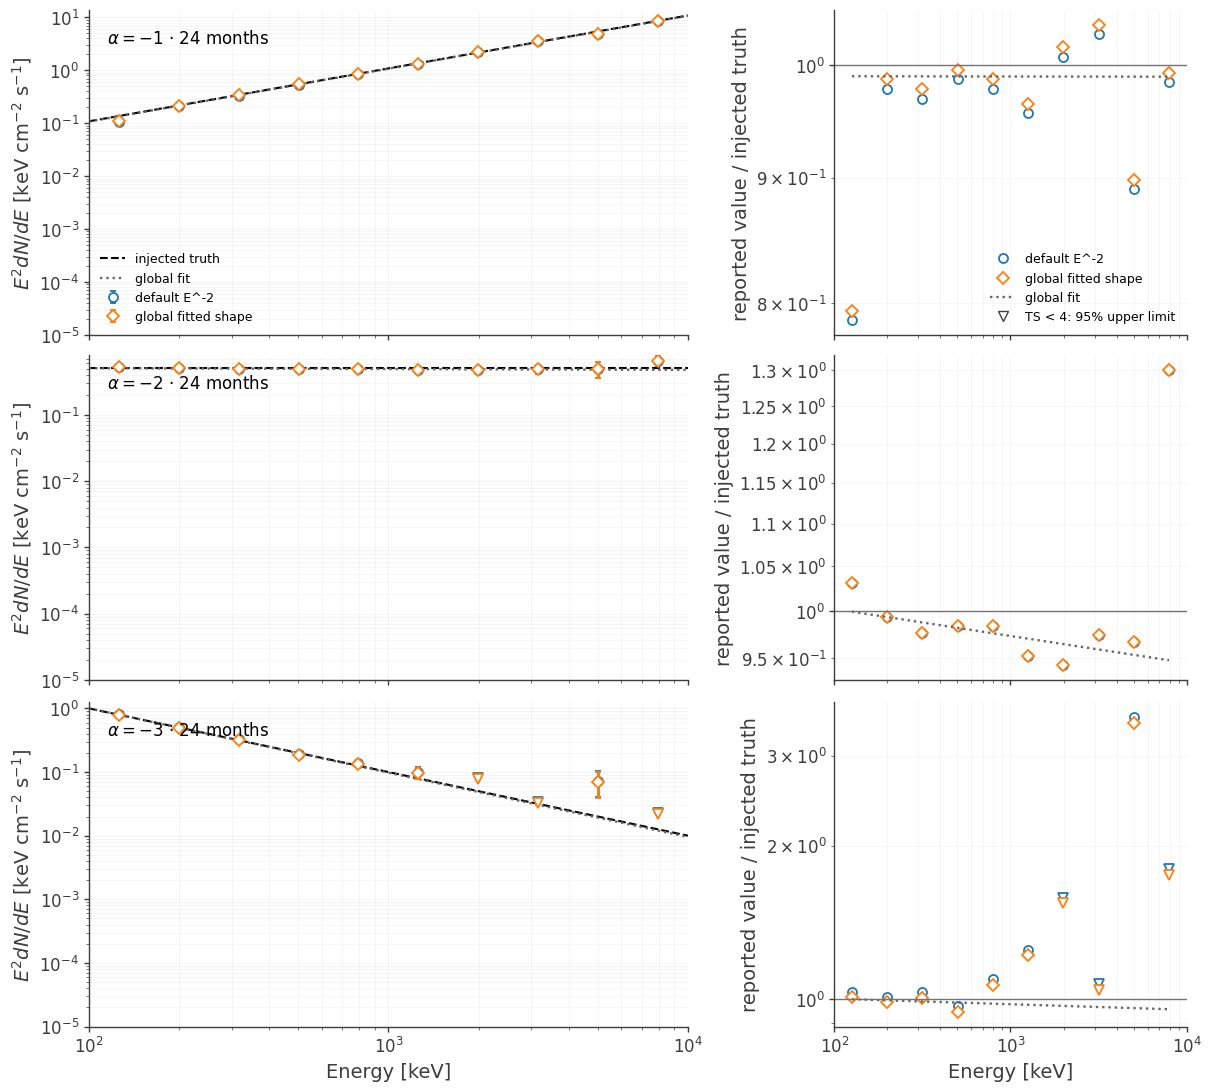

In [15]:
plot_family_comparison(
    "powerlaw", comparison_runs_24m, sed_results_24m,
    exposure_months=LONG_EXPOSURE_MONTHS,
)

### 24-month cutoff-power-law comparison

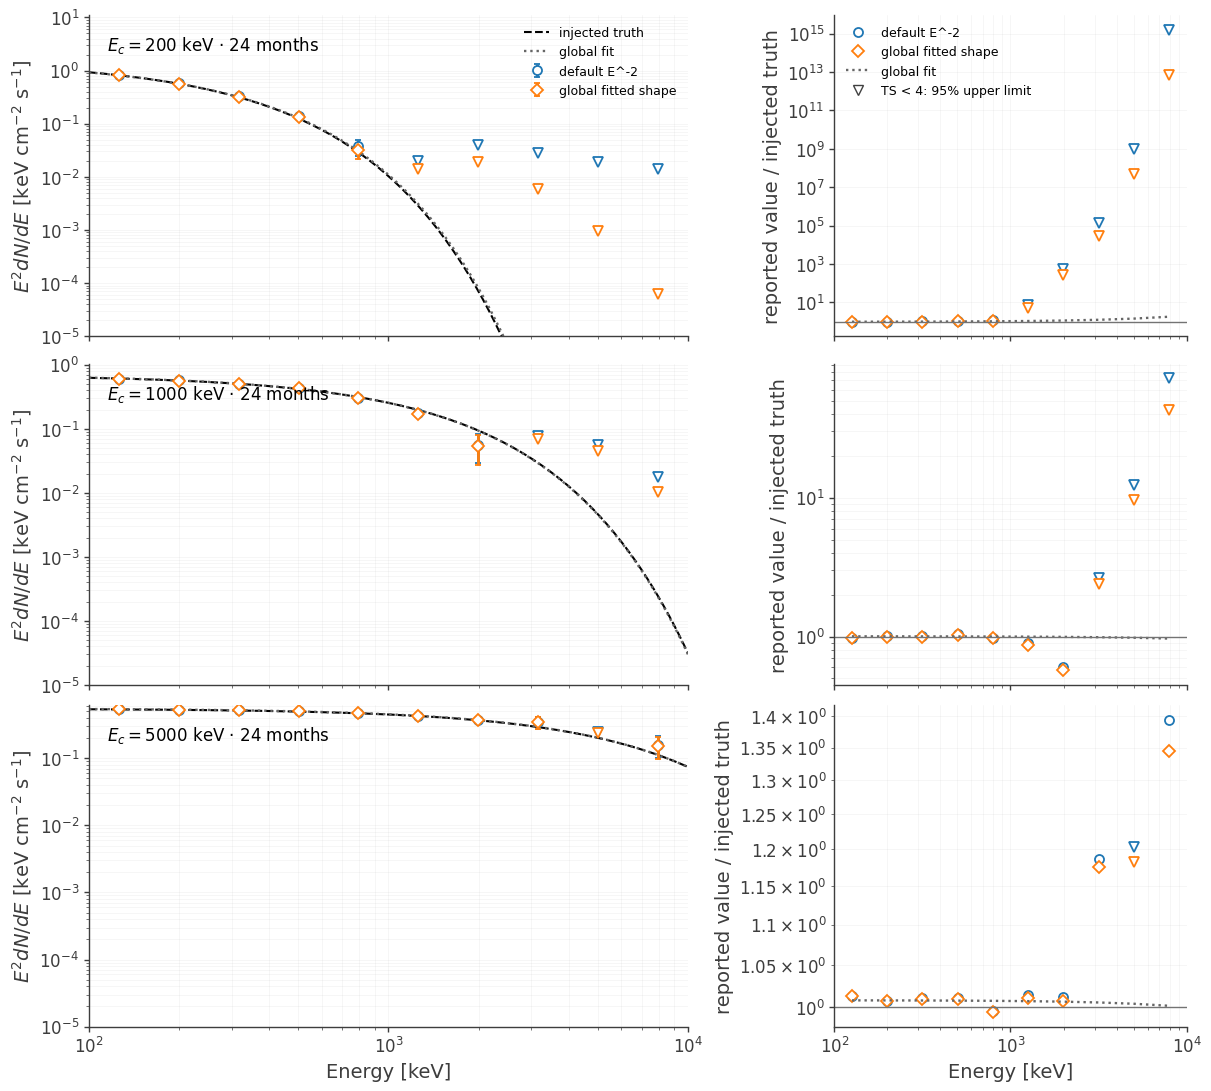

In [16]:
plot_family_comparison(
    "cutoff_powerlaw", comparison_runs_24m, sed_results_24m,
    exposure_months=LONG_EXPOSURE_MONTHS,
)